In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, matthews_corrcoef, precision_recall_curve, roc_auc_score, roc_curve

import pandas as pd
import numpy as np
import ast
from sklearn.metrics import confusion_matrix, matthews_corrcoef, precision_recall_curve, roc_auc_score, auc

def binary_entropy(p):
    """Calculates Shannon entropy for binary probabilities."""
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))

def calc_aleatoric(probs_list):
    """Calculates aleatoric uncertainty (mean of individual entropies)."""
    entropies = [binary_entropy(p) for p in probs_list]
    return np.mean(entropies)

def evaluate_tte_performance(ensemble_path, dataset_path, target_sensitivity=0.85):
    """
    Evaluates ensemble model performance across Time-to-Event buckets.
    """
    # 1. Load Data
    ensemble_df = pd.read_csv(ensemble_path)
    dataset_df = pd.read_csv(dataset_path) 

    # 2. Merge Data
    eval_df = ensemble_df.merge(
        dataset_df[['subject_id', 'month', 'months_to_conversion']], 
        on=['subject_id', 'month'], 
        how='left'
    )

    # 3. Define Buckets
    bins = [0, 6, 12, 18, 24, 30, 36]
    labels = ['0-6m', '6-12m', '12-18m', '18-24m', '24-30m', '30-36m']
    eval_df['tte_bucket'] = pd.cut(
        eval_df['months_to_conversion'], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
    )

    # 4. Parse Arrays and Calculate Uncertainty
    eval_df['all_probs'] = eval_df['all_probs'].apply(ast.literal_eval)
    eval_df['total_uncertainty'] = eval_df['mu'].apply(binary_entropy)
    eval_df['aleatoric_uncertainty'] = eval_df['all_probs'].apply(calc_aleatoric)
    eval_df['epistemic_uncertainty'] = eval_df['total_uncertainty'] - eval_df['aleatoric_uncertainty']

    # 5. Evaluate Buckets
    stable_mask = eval_df['label'] == 0
    stable_df = eval_df[stable_mask]
    results = []

    for bucket in labels:
        bucket_mask = (eval_df['label'] == 1) & (eval_df['tte_bucket'] == bucket)
        bucket_df = eval_df[bucket_mask]
        
        if len(bucket_df) == 0:
            continue
            
        combined_df = pd.concat([stable_df, bucket_df])
        y_true = combined_df['label']
        y_probs = combined_df['mu']
        
        # Calculate AUC & PRC
        auc_ensemble = roc_auc_score(y_true, y_probs)
        precision, recall, _ = precision_recall_curve(y_true, y_probs)
        prc_ensemble = auc(recall, precision) # <-- Safer PRC calculation
        
        # Find Threshold
        target_threshold = np.percentile(bucket_df['mu'], 100 * (1 - target_sensitivity))
        
        # Hard Predictions & CM
        y_pred = (y_probs >= target_threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        mcc = matthews_corrcoef(y_true, y_pred)

        # Clinical Metrics
        actual_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        tot_unc = bucket_df['total_uncertainty'].mean()
        
        results.append({
            'Time to Event': bucket,
            'Pos Cases': len(bucket_df),
            'AUC': round(auc_ensemble, 3),
            'PRC': round(prc_ensemble, 3),
            'MCC': round(mcc, 3),
            'Req. Threshold': round(target_threshold, 3),
            'TP': tp, 'FN': fn, 'TN': tn, 'FP': fp,
            'Sensitivity': round(actual_sensitivity, 3),
            'Specificity': round(specificity, 3),
            'Tot Unc': round(tot_unc, 3),
        })

    return pd.DataFrame(results)





df_results = evaluate_tte_performance(
    '../results/classification/mci_ad_conversion/label_36m/aggregated/patient_mean_probs_label_36m_mci_ad_conversion_model.csv',
    '../data/adni/adni_rolling_locf_36m.csv'
)
print(df_results)

  Time to Event  Pos Cases    AUC    PRC    MCC  Req. Threshold   TP  FN   TN  \
0          0-6m        138  0.921  0.872  0.603           0.692  117  21  239   
1         6-12m        165  0.879  0.824  0.559           0.639  140  25  222   
2        12-18m        100  0.842  0.710  0.432           0.559   85  15  196   
3        18-24m         81  0.804  0.640  0.285           0.452   68  13  153   
4        24-30m         45  0.768  0.465  0.214           0.432   38   7  142   
5        30-36m         45  0.753  0.375  0.214           0.432   38   7  142   

    FP  Sensitivity  Specificity  Tot Unc  
0   63        0.848        0.791    0.622  
1   80        0.848        0.735    0.687  
2  106        0.850        0.649    0.715  
3  149        0.840        0.507    0.724  
4  160        0.844        0.470    0.769  
5  160        0.844        0.470    0.808  


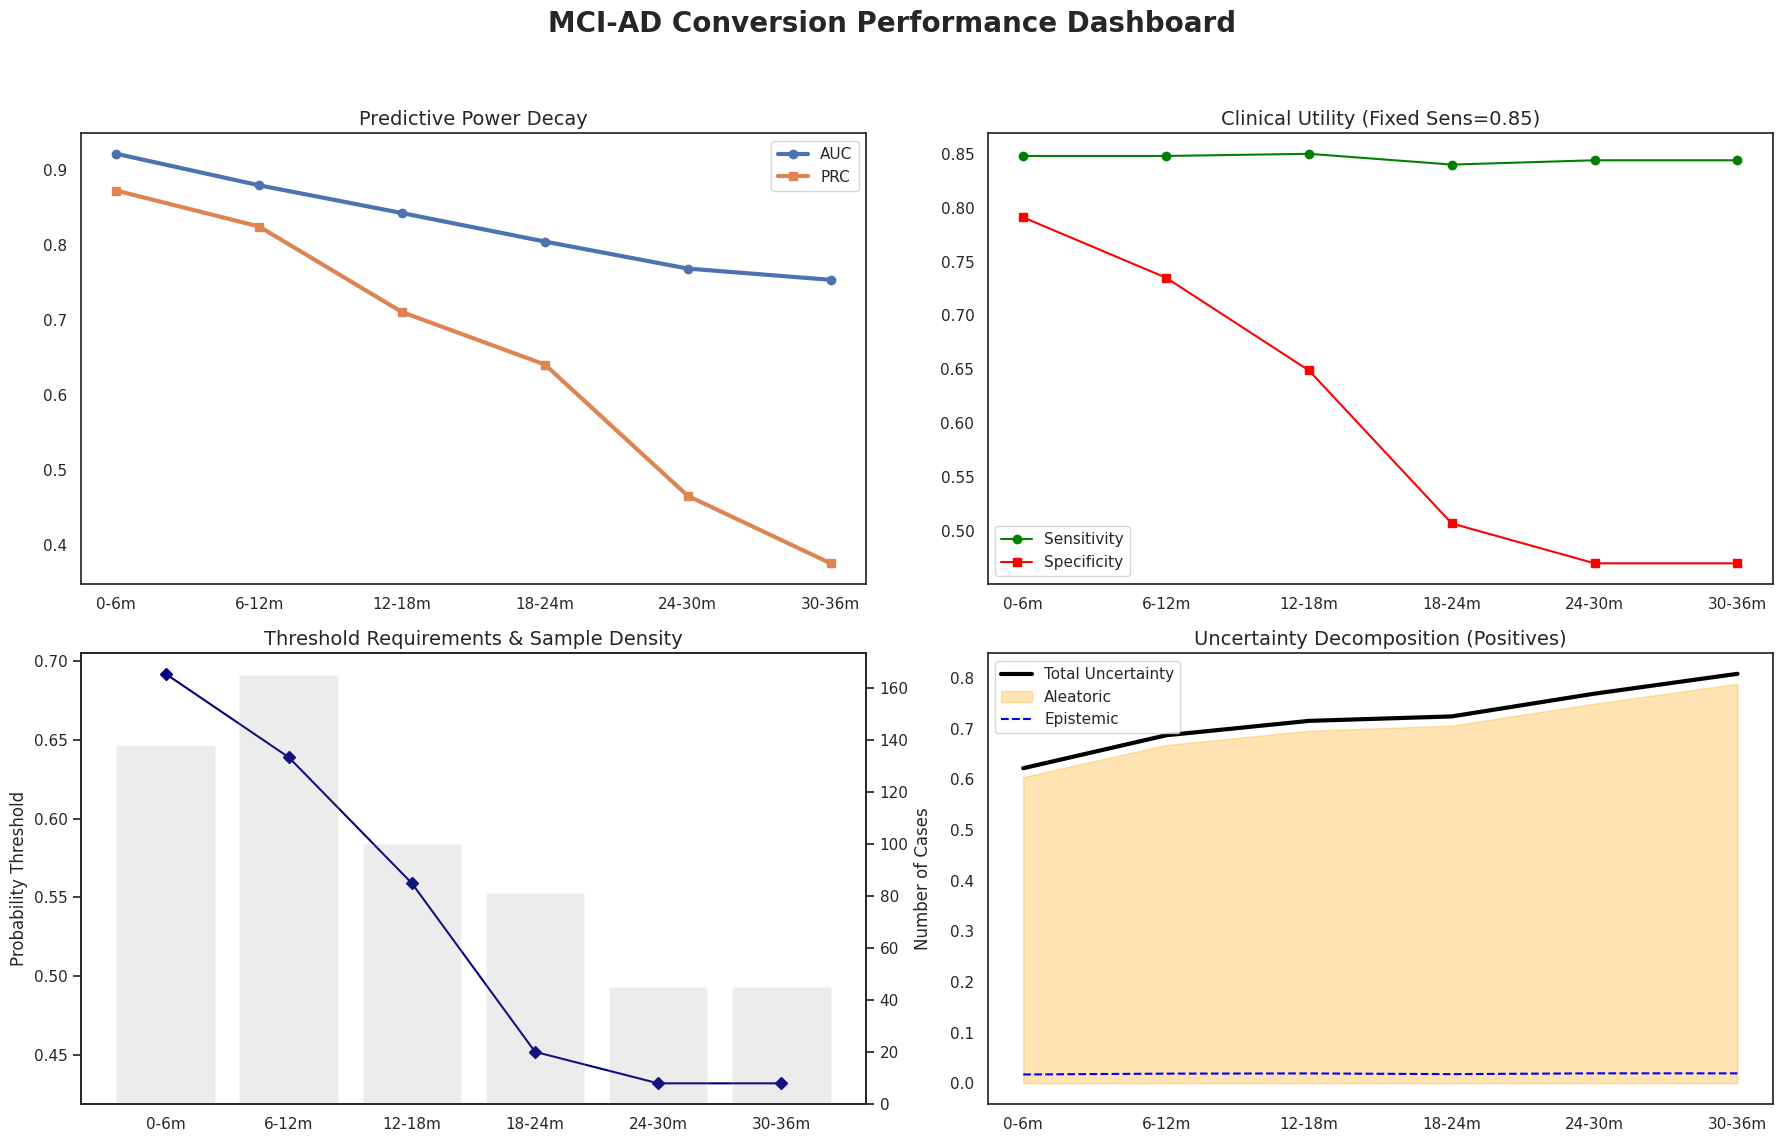

In [4]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, matthews_corrcoef, precision_recall_curve, roc_auc_score, auc

# --- 1. Utility Functions for Uncertainty ---
def binary_entropy(p):
    """Calculates Shannon entropy for binary probabilities."""
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))

def calc_aleatoric(probs_list):
    """Calculates aleatoric uncertainty (mean of individual entropies)."""
    return np.mean([binary_entropy(p) for p in probs_list])

# --- 2. Main Evaluation Logic ---
def run_tte_evaluation(ensemble_path, dataset_path, target_sensitivity=0.85):
    """
    Loads data, merges, calculates uncertainty, and computes bucketed metrics.
    Returns: (eval_df, df_results)
    """
    # Load Data
    ensemble_df = pd.read_csv(ensemble_path)
    dataset_df = pd.read_csv(dataset_path) 

    # Merge Data
    eval_df = ensemble_df.merge(
        dataset_df[['subject_id', 'month', 'months_to_conversion']], 
        on=['subject_id', 'month'], 
        how='left'
    )

    # Define Buckets
    bins = [0, 6, 12, 18, 24, 30, 36]
    labels = ['0-6m', '6-12m', '12-18m', '18-24m', '24-30m', '30-36m']
    eval_df['tte_bucket'] = pd.cut(
        eval_df['months_to_conversion'], 
        bins=bins, labels=labels, include_lowest=True
    )

    # Calculate Row-Level Uncertainties (The eval_df part)
    eval_df['all_probs'] = eval_df['all_probs'].apply(ast.literal_eval)
    eval_df['total_uncertainty'] = eval_df['mu'].apply(binary_entropy)
    eval_df['aleatoric_uncertainty'] = eval_df['all_probs'].apply(calc_aleatoric)
    eval_df['epistemic_uncertainty'] = eval_df['total_uncertainty'] - eval_df['aleatoric_uncertainty']

    # Compute Summary Results (The df_results part)
    stable_df = eval_df[eval_df['label'] == 0]
    results = []

    for bucket in labels:
        bucket_mask = (eval_df['label'] == 1) & (eval_df['tte_bucket'] == bucket)
        bucket_df = eval_df[bucket_mask]
        
        if len(bucket_df) == 0: continue
            
        combined_df = pd.concat([stable_df, bucket_df])
        y_true, y_probs = combined_df['label'], combined_df['mu']
        
        # Metrics
        auc_score = roc_auc_score(y_true, y_probs)
        precision, recall, _ = precision_recall_curve(y_true, y_probs)
        prc_score = auc(recall, precision)
        
        # Dynamic Thresholding for Sensitivity
        threshold = np.percentile(bucket_df['mu'], 100 * (1 - target_sensitivity))
        y_pred = (y_probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        results.append({
            'Time to Event': bucket,
            'Pos Cases': len(bucket_df),
            'AUC': round(auc_score, 3),
            'PRC': round(prc_score, 3),
            'MCC': round(matthews_corrcoef(y_true, y_pred), 3),
            'Req. Threshold': round(threshold, 3),
            'TP': tp, 'FN': fn, 'TN': tn, 'FP': fp,
            'Sensitivity': round(tp/(tp+fn), 3),
            'Specificity': round(tn/(tn+fp), 3),
            'Tot Unc': round(bucket_df['total_uncertainty'].mean(), 3),
        })

    return eval_df, pd.DataFrame(results)

# --- 3. Dashboard Visualization ---
def plot_comprehensive_dashboard(df_results, eval_df):
    sns.set_theme(style="white")
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('MCI-AD Conversion Performance Dashboard', fontsize=20, fontweight='bold')
    
    x = df_results['Time to Event']
    
    # Plot 1: Performance Decay
    axes[0,0].plot(x, df_results['AUC'], marker='o', label='AUC', linewidth=3)
    axes[0,0].plot(x, df_results['PRC'], marker='s', label='PRC', linewidth=3)
    axes[0,0].set_title('Predictive Power Decay', fontsize=14)
    axes[0,0].legend()

    # Plot 2: Clinical Metrics
    axes[0,1].plot(x, df_results['Sensitivity'], marker='o', color='green', label='Sensitivity')
    axes[0,1].plot(x, df_results['Specificity'], marker='s', color='red', label='Specificity')
    axes[0,1].set_title('Clinical Utility (Fixed Sens=0.85)', fontsize=14)
    axes[0,1].legend()

    # Plot 3: Threshold & Density
    ax3_twin = axes[1,0].twinx()
    ax3_twin.bar(x, df_results['Pos Cases'], color='gray', alpha=0.15, label='N Pos Cases')
    axes[1,0].plot(x, df_results['Req. Threshold'], marker='D', color='navy', label='Threshold')
    axes[1,0].set_title('Threshold Requirements & Sample Density', fontsize=14)
    axes[1,0].set_ylabel('Probability Threshold')
    ax3_twin.set_ylabel('Number of Cases')

    # Plot 4: Uncertainty Decomposition
    pos_unc = eval_df[eval_df['label'] == 1].groupby('tte_bucket', observed=True).mean(numeric_only=True)
    axes[1,1].plot(x, pos_unc['total_uncertainty'], color='black', lw=3, label='Total Uncertainty')
    axes[1,1].fill_between(x, 0, pos_unc['aleatoric_uncertainty'], color='orange', alpha=0.3, label='Aleatoric')
    axes[1,1].plot(x, pos_unc['epistemic_uncertainty'], '--', color='blue', label='Epistemic')
    axes[1,1].set_title('Uncertainty Decomposition (Positives)', fontsize=14)
    axes[1,1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 4. Execution ---
eval_df, df_results = run_tte_evaluation('../results/classification/mci_ad_conversion/label_36m/aggregated/patient_mean_probs_label_36m_mci_ad_conversion_model.csv',
    '../data/adni/adni_rolling_locf_36m.csv')
plot_comprehensive_dashboard(df_results, eval_df)